In [4]:
# ── Test complet sans pipeline.py ────────────────────────────
import numpy as np
import librosa
import tensorflow as tf
import subprocess, os
import scipy.io.wavfile as wavfile
from sklearn.preprocessing import LabelEncoder
from scipy import signal as scipy_signal
from collections import Counter

# Paramètres
TARGET_SR   = 16000
SEG_LEN     = 8000
HOP_LEN_AUD = 4000
N_MELS, N_FFT, HOP_LEN_MEL = 64, 512, 160

# Charger modèle
MODEL_PATH = r'C:\Users\asalou\S7\stages7\project\augmentation\aug\cnn2d_best_ov.keras'
Y_RAW_PATH = r'C:\Users\asalou\S7\stages7\project\augmentation\aug\y_augmented_ov.npy'
AUDIO_PATH = r'C:\Users\asalou\S7\stages7\project\raw_audio\Audio_1.m4a'

model = tf.keras.models.load_model(MODEL_PATH)
y_raw = np.load(Y_RAW_PATH, allow_pickle=True)
le    = LabelEncoder()
le.fit(y_raw)
print(f"Classes : {le.classes_}")

# ── Convertir .m4a → .wav via ffmpeg ─────────────────────────
tmp_wav = r'C:\Users\asalou\AppData\Local\Temp\test_audio.wav'
ret = subprocess.run(
    ['ffmpeg', '-i', AUDIO_PATH, '-ar', '16000', '-ac', '1',
     tmp_wav, '-y'],
    capture_output=True, text=True
)
print(f"ffmpeg return code : {ret.returncode}")
if ret.returncode != 0:
    print(f"ffmpeg stderr :\n{ret.stderr[-500:]}")
else:
    print(f"✅ WAV créé : {os.path.exists(tmp_wav)}")

# ── Charger le WAV ────────────────────────────────────────────
sr_file, data = wavfile.read(tmp_wav)
print(f"Signal : shape={data.shape}  dtype={data.dtype}  sr={sr_file}")

# Normaliser
data = data.astype(np.float32)
data /= np.max(np.abs(data)) + 1e-9

# Filtrer
nyq  = sr_file / 2
b, a = scipy_signal.butter(5, [100/nyq, 6000/nyq], btype='band')
filt = scipy_signal.filtfilt(b, a, data)
print(f"Signal filtré : {len(filt)} samples = {len(filt)/sr_file:.1f}s")

# ── Segmenter ─────────────────────────────────────────────────
segments = []
pos = 0
while pos + SEG_LEN <= len(filt):
    segments.append(filt[pos:pos + SEG_LEN])
    pos += HOP_LEN_AUD
print(f"Segments : {len(segments)}")

# ── Mel + prédiction ──────────────────────────────────────────
def to_mel(seg):
    mel    = librosa.feature.melspectrogram(
        y=seg.astype(float), sr=TARGET_SR,
        n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LEN_MEL, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    return ((mel_db - mn) / (mx - mn + 1e-9)).astype(np.float32)

X_mel  = np.array([to_mel(s) for s in segments])[..., np.newaxis]
print(f"X_mel shape : {X_mel.shape}")

probas      = model.predict(X_mel, verbose=0)
labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))

# ── Résultats ─────────────────────────────────────────────────
counts = Counter(labels_pred)
n_miction = counts.get('miction_active', 0)
duree_s   = round(n_miction * 0.25, 2)

print(f"\nRésultats Audio_1 :")
print(f"  Durée miction  : {duree_s}s  (attendu ~13.5s)")
print(f"\nDistribution :")
for lbl, cnt in counts.most_common():
    print(f"  {lbl:20s} : {cnt:4d}  ({cnt/len(labels_pred)*100:.1f}%)")

print(f"\n10 premiers labels : {labels_pred[:10]}")
print(f"10 derniers labels  : {labels_pred[-10:]}")

Classes : ['bruit_ambiant' 'bruit_chasse' 'miction_active' 'silence']
ffmpeg return code : 0
✅ WAV créé : True
Signal : shape=(676523,)  dtype=int16  sr=16000
Signal filtré : 676523 samples = 42.3s
Segments : 168
X_mel shape : (168, 64, 51, 1)

Résultats Audio_1 :
  Durée miction  : 4.25s  (attendu ~13.5s)

Distribution :
  bruit_chasse         :   72  (42.9%)
  bruit_ambiant        :   51  (30.4%)
  silence              :   28  (16.7%)
  miction_active       :   17  (10.1%)

10 premiers labels : [np.str_('silence'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant'), np.str_('bruit_ambiant')]
10 derniers labels  : [np.str_('bruit_chasse'), np.str_('bruit_chasse'), np.str_('bruit_chasse'), np.str_('bruit_chasse'), np.str_('bruit_chasse'), np.str_('bruit_chasse'), np.str_('bruit_ambiant'), np.str_('bruit_chasse'), np.str_('bruit_chas

In [20]:
# ── Vérifier tous les modèles disponibles ────────────────────
import os

output_dir = r'C:\Users\asalou\S7\stages7\project\augmentation\aug'
print("Modèles disponibles :")
for f in os.listdir(output_dir):
    if f.endswith('.keras') or f.endswith('.h5'):
        taille = os.path.getsize(os.path.join(output_dir, f)) / 1024
        print(f"  {f:45s} : {taille:.1f} KB")

Modèles disponibles :
  cnn2d_best.keras                              : 2032.6 KB
  cnn_lstm_best.keras                           : 9452.7 KB


In [22]:
# ── Tester avec chaque modèle disponible ─────────────────────
modeles_a_tester = [
    r'C:\Users\asalou\S7\stages7\project\augmentation\aug\cnn2d_best.keras',
    # Ajoutez ici les autres .keras trouvés
]

for model_path in modeles_a_tester:
    if not os.path.exists(model_path):
        continue

    print(f"\n{'='*55}")
    print(f"Modèle : {os.path.basename(model_path)}")

    m = tf.keras.models.load_model(model_path)
    print(f"Input shape : {m.input_shape}")

    probas_t      = m.predict(X_mel, verbose=0)
    labels_t      = list(le.inverse_transform(np.argmax(probas_t, axis=1)))
    counts_t      = Counter(labels_t)
    n_miction_t   = counts_t.get('miction_active', 0)
    duree_t       = round(n_miction_t * 0.25, 2)

    print(f"Durée miction : {duree_t}s")
    for lbl, cnt in counts_t.most_common():
        print(f"  {lbl:20s} : {cnt:3d} ({cnt/len(labels_t)*100:.1f}%)")


Modèle : cnn2d_best.keras
Input shape : (None, 64, 51, 1)
Durée miction : 8.0s
  bruit_chasse         :  81 (48.2%)
  silence              :  32 (19.0%)
  miction_active       :  32 (19.0%)
  bruit_ambiant        :  23 (13.7%)


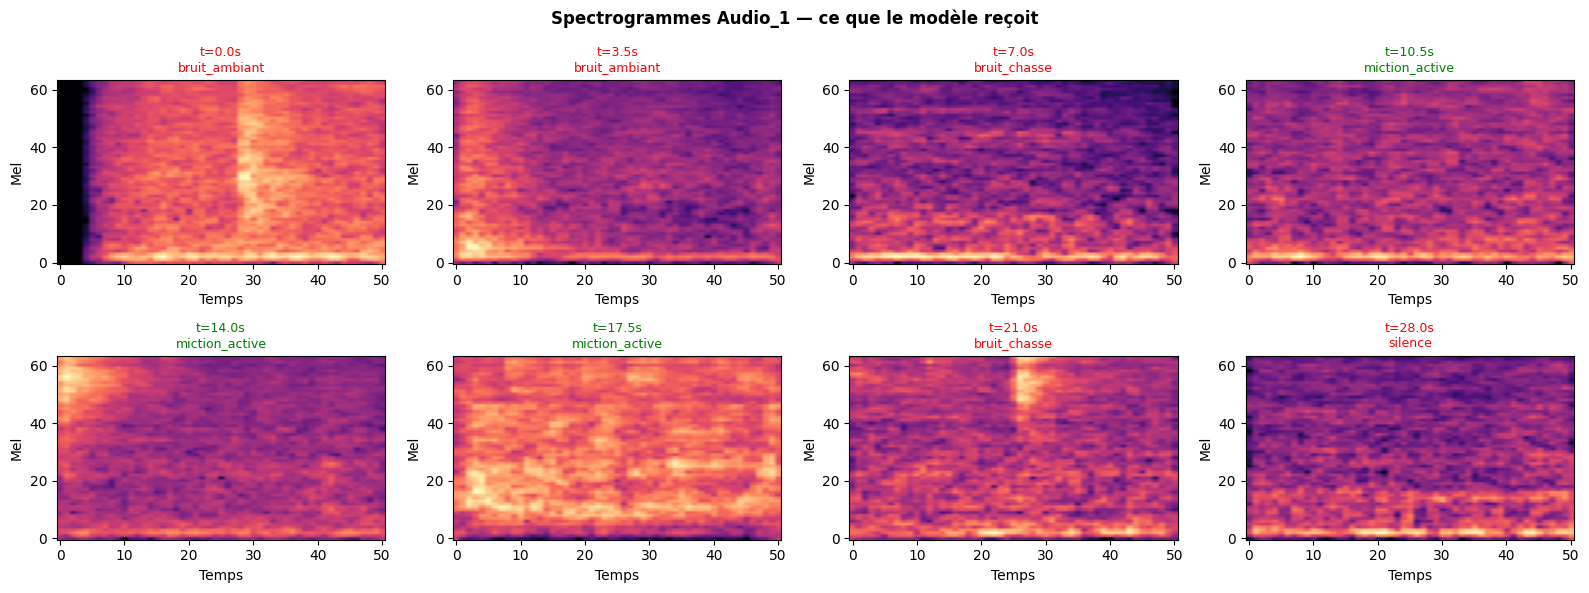

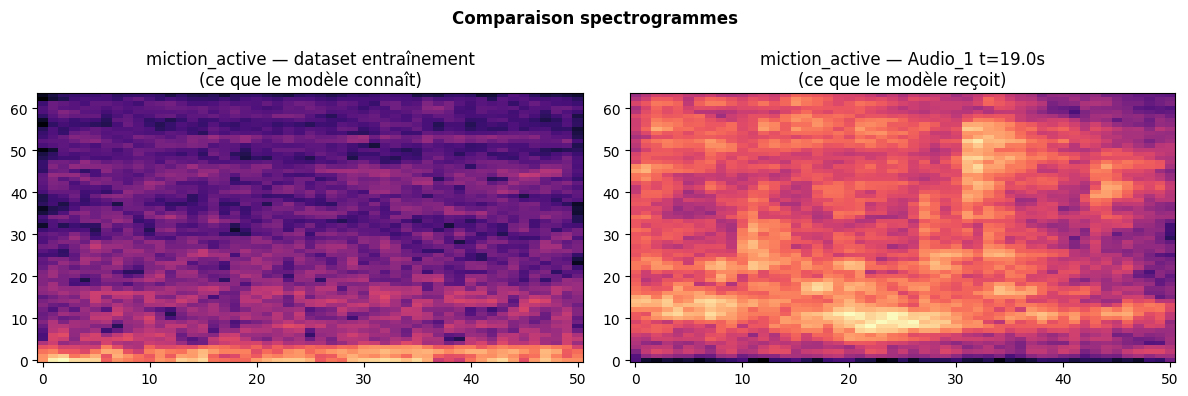


Stats X_mel entraînement vs Audio_1 :
  Train — min=0.000 max=1.000 moy=0.424
  Test  — min=0.000       max=1.000       moy=0.514


In [24]:
# ── Visualiser quelques spectrogrammes de Audio_1 ────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Spectrogrammes Audio_1 — ce que le modèle reçoit', fontweight='bold')

# Segments au milieu de l'enregistrement (là où la miction devrait être)
# Audio_1 : miction attendue vers t=7s → segment ~56 (7s/0.25s)
indices = [0, 14, 28, 42, 56, 70, 84, 112]

for ax, idx in zip(axes.flat, indices):
    if idx < len(X_mel):
        spec = X_mel[idx, :, :, 0]
        t_s  = round(idx * 0.25, 1)
        lbl  = labels_pred[idx]
        ax.imshow(spec, origin='lower', aspect='auto',
                  cmap='magma', vmin=0, vmax=1)
        ax.set_title(f't={t_s}s\n{lbl}', fontsize=9,
                     color='green' if lbl=='miction_active' else 'red')
        ax.set_xlabel('Temps'); ax.set_ylabel('Mel')

plt.tight_layout()
plt.savefig('debug_spectrogrammes.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Comparer avec ce que le modèle a vu pendant l'entraînement ──
# Charger un segment miction_active du dataset original
X_mel_train = np.load(
    r'C:\Users\asalou\S7\stages7\project\augmentation\aug\X_mel.npy')
y_enc_train = np.load(
    r'C:\Users\asalou\S7\stages7\project\augmentation\aug\y_enc.npy')

# Trouver un exemple de miction_active dans le dataset d'entraînement
idx_miction = np.where(y_enc_train == le.transform(['miction_active'])[0])[0][0]
spec_train  = X_mel_train[idx_miction, :, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Comparaison spectrogrammes', fontweight='bold')

axes[0].imshow(spec_train, origin='lower', aspect='auto', cmap='magma')
axes[0].set_title('miction_active — dataset entraînement\n(ce que le modèle connaît)')

# Prendre le segment le plus confiant en miction_active de Audio_1
conf_miction = [(i, probas[i, le.transform(['miction_active'])[0]])
                for i in range(len(labels_pred))
                if labels_pred[i] == 'miction_active']

if conf_miction:
    best_idx = max(conf_miction, key=lambda x: x[1])[0]
    spec_test = X_mel[best_idx, :, :, 0]
    axes[1].imshow(spec_test, origin='lower', aspect='auto', cmap='magma')
    axes[1].set_title(f'miction_active — Audio_1 t={best_idx*0.25:.1f}s\n(ce que le modèle reçoit)')
else:
    axes[1].set_title('Aucun segment miction_active détecté')

plt.tight_layout()
plt.savefig('debug_comparaison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nStats X_mel entraînement vs Audio_1 :")
print(f"  Train — min={X_mel_train.min():.3f} max={X_mel_train.max():.3f} moy={X_mel_train.mean():.3f}")
print(f"  Test  — min={X_mel.min():.3f}       max={X_mel.max():.3f}       moy={X_mel.mean():.3f}")

In [25]:
# ── Comparer les pipelines de normalisation ───────────────────

# Pipeline entraînement (Jupyter) :
# filtrer_signal → normalise par max absolu GLOBAL du signal entier
# signal_to_melspec → normalise le mel par son propre min/max

# Pipeline Flask (pipeline.py) :
# même filtrer_signal ?
# même signal_to_melspec ?

# Vérification — recalculer le même segment avec les deux pipelines
import numpy as np

# Charger un segment original depuis X_augmented
X_raw = np.load(
    r'C:\Users\asalou\S7\stages7\project\augmentation\aug\X_augmented.npy')
seg_orig = X_raw[0]  # premier segment

# Pipeline entraînement
def to_mel_train(seg):
    mel    = librosa.feature.melspectrogram(
        y=seg.astype(float), sr=16000,
        n_mels=64, n_fft=512, hop_length=160, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    return ((mel_db - mn) / (mx - mn + 1e-9)).astype(np.float32)

# Pipeline Audio_1 (depuis le WAV converti)
seg_audio1 = segments[56]  # segment vers t=14s

mel_train  = to_mel_train(seg_orig)
mel_test   = to_mel_train(seg_audio1)

print(f"Segment entraînement — moy={mel_train.mean():.3f}  std={mel_train.std():.3f}")
print(f"Segment Audio_1      — moy={mel_test.mean():.3f}  std={mel_test.std():.3f}")

# ── Prédire les deux ─────────────────────────────────────────
pred_train = model.predict(mel_train[np.newaxis, ..., np.newaxis], verbose=0)
pred_test  = model.predict(mel_test[np.newaxis,  ..., np.newaxis], verbose=0)

print(f"\nPrédiction segment entraînement :")
for i, lbl in enumerate(le.classes_):
    print(f"  {lbl:20s} : {pred_train[0,i]:.3f}")

print(f"\nPrédiction segment Audio_1 t=14s :")
for i, lbl in enumerate(le.classes_):
    print(f"  {lbl:20s} : {pred_test[0,i]:.3f}")

# ── Vérifier l'amplitude du signal ────────────────────────────
print(f"\nAmplitude signal entraînement : max={np.max(np.abs(seg_orig)):.4f}")
print(f"Amplitude signal Audio_1      : max={np.max(np.abs(seg_audio1)):.4f}")

Segment entraînement — moy=0.359  std=0.139
Segment Audio_1      — moy=0.484  std=0.107

Prédiction segment entraînement :
  bruit_ambiant        : 0.001
  bruit_chasse         : 0.000
  miction_active       : 0.999
  silence              : 0.001

Prédiction segment Audio_1 t=14s :
  bruit_ambiant        : 0.000
  bruit_chasse         : 0.001
  miction_active       : 0.999
  silence              : 0.000

Amplitude signal entraînement : max=0.0070
Amplitude signal Audio_1      : max=0.1049


In [26]:
# ── Diagnostic complet segment par segment ────────────────────
print("Analyse segment par segment Audio_1 :")
print("="*65)
print(f"{'idx':>4} | {'t(s)':>6} | {'label':20s} | {'conf':>6} | {'miction':>8}")
print("="*65)

for i in range(min(len(segments), 168)):
    seg    = segments[i]
    t_s    = round(i * 0.25, 2)
    mel    = to_mel_train(seg)
    pred   = model.predict(mel[np.newaxis,...,np.newaxis], verbose=0)[0]
    lbl    = le.classes_[np.argmax(pred)]
    conf   = np.max(pred)
    p_mic  = pred[le.transform(['miction_active'])[0]]

    marker = " ←" if lbl == 'miction_active' else ""
    print(f"{i:>4} | {t_s:>6} | {lbl:20s} | {conf:.3f} | {p_mic:.3f}{marker}")

Analyse segment par segment Audio_1 :
 idx |   t(s) | label                |   conf |  miction
   0 |    0.0 | bruit_ambiant        | 0.693 | 0.000
   1 |   0.25 | bruit_ambiant        | 1.000 | 0.000
   2 |    0.5 | bruit_ambiant        | 1.000 | 0.000
   3 |   0.75 | bruit_ambiant        | 1.000 | 0.000
   4 |    1.0 | bruit_ambiant        | 1.000 | 0.000
   5 |   1.25 | bruit_ambiant        | 0.920 | 0.000
   6 |    1.5 | bruit_chasse         | 0.998 | 0.000
   7 |   1.75 | bruit_chasse         | 0.999 | 0.000
   8 |    2.0 | bruit_ambiant        | 1.000 | 0.000
   9 |   2.25 | bruit_ambiant        | 1.000 | 0.000
  10 |    2.5 | bruit_ambiant        | 1.000 | 0.000
  11 |   2.75 | bruit_ambiant        | 1.000 | 0.000
  12 |    3.0 | bruit_ambiant        | 1.000 | 0.000
  13 |   3.25 | bruit_ambiant        | 0.998 | 0.000
  14 |    3.5 | bruit_ambiant        | 0.992 | 0.000
  15 |   3.75 | silence              | 0.997 | 0.000
  16 |    4.0 | bruit_chasse         | 1.000 | 0.000
  17

In [27]:
# ── Correction avec seuil de confiance ───────────────────────
def corriger_avec_seuil(labels_pred, probas, le, seuil=0.60, fenetre=2):
    """
    Correction contextuelle + seuil de confiance.
    Si confiance < seuil → prend le label du voisin majoritaire.
    """
    labels = list(labels_pred)
    n      = len(labels)
    idx_miction = le.transform(['miction_active'])[0]

    for i in range(fenetre, n - fenetre):
        conf = np.max(probas[i])
        
        # Si segment peu confiant → regarder le contexte
        if conf < seuil:
            voisins = labels[i-fenetre:i] + labels[i+1:i+fenetre+1]
            from collections import Counter
            vote = Counter(voisins).most_common(1)[0][0]
            labels[i] = vote
            continue

        # Correction contextuelle standard
        if labels[i-1] == labels[i+1] != labels[i]:
            labels[i] = labels[i-1]

    return labels

# ── Appliquer et comparer ─────────────────────────────────────
labels_brut  = list(le.inverse_transform(np.argmax(probas, axis=1)))
labels_corr  = corriger_avec_seuil(labels_brut, probas, le,
                                    seuil=0.60, fenetre=2)

from collections import Counter
counts_brut = Counter(labels_brut)
counts_corr = Counter(labels_corr)

n_mic_brut  = counts_brut.get('miction_active', 0)
n_mic_corr  = counts_corr.get('miction_active', 0)

print("="*55)
print(f"{'':25s} | {'Avant':>8} | {'Après':>8}")
print("="*55)
for lbl in le.classes_:
    b = counts_brut.get(lbl, 0)
    c = counts_corr.get(lbl, 0)
    print(f"  {lbl:20s} | {b:8d} | {c:8d}")
print("="*55)
print(f"  Durée miction avant : {n_mic_brut * 0.25:.1f}s")
print(f"  Durée miction après : {n_mic_corr * 0.25:.1f}s")
print(f"  Attendu             : ~13.5s")

                          |    Avant |    Après
  bruit_ambiant        |       23 |       20
  bruit_chasse         |       81 |       81
  miction_active       |       32 |       34
  silence              |       32 |       33
  Durée miction avant : 8.0s
  Durée miction après : 8.5s
  Attendu             : ~13.5s


In [28]:
# ── Charger les vrais labels de Audio_1 ──────────────────────
import json

with open(r'C:\Users\asalou\S7\stages7\project\augmentation\aug\labels_segments.json') as f:
    labels_check = json.load(f)

labels_vrais_audio1 = labels_check.get('Audio_1', [])
print(f"Nb labels vrais : {len(labels_vrais_audio1)}")
print(f"Distribution vraie :")
print(Counter(labels_vrais_audio1))

# ── Aligner vrais labels vs prédictions ──────────────────────
# Labels vrais = segments 500ms sans chevauchement
# Labels prédits = segments 500ms avec chevauchement 50%
# → il faut mapper les vrais labels sur les segments chevauchants

print("\nComparaison vrai vs prédit (premiers 60 segments) :")
print(f"{'idx':>4} | {'t(s)':>6} | {'vrai':20s} | {'prédit':20s} | {'ok':>4}")
print("="*65)

for i in range(min(60, len(labels_brut))):
    t_s      = round(i * 0.25, 2)
    orig_id  = min(int(t_s / 0.5), len(labels_vrais_audio1) - 1)
    vrai     = labels_vrais_audio1[orig_id]
    predit   = labels_brut[i]
    ok       = "✅" if vrai == predit else "❌"
    print(f"{i:>4} | {t_s:>6} | {vrai:20s} | {predit:20s} | {ok}")

Nb labels vrais : 84
Distribution vraie :
Counter({'miction_active': 37, 'bruit_chasse': 20, 'bruit_ambiant': 14, 'silence': 13})

Comparaison vrai vs prédit (premiers 60 segments) :
 idx |   t(s) | vrai                 | prédit               |   ok
   0 |    0.0 | bruit_ambiant        | bruit_ambiant        | ✅
   1 |   0.25 | bruit_ambiant        | bruit_ambiant        | ✅
   2 |    0.5 | bruit_ambiant        | bruit_ambiant        | ✅
   3 |   0.75 | bruit_ambiant        | bruit_ambiant        | ✅
   4 |    1.0 | bruit_ambiant        | bruit_ambiant        | ✅
   5 |   1.25 | bruit_ambiant        | bruit_ambiant        | ✅
   6 |    1.5 | bruit_ambiant        | bruit_chasse         | ❌
   7 |   1.75 | bruit_ambiant        | bruit_chasse         | ❌
   8 |    2.0 | bruit_ambiant        | bruit_ambiant        | ✅
   9 |   2.25 | bruit_ambiant        | bruit_ambiant        | ✅
  10 |    2.5 | bruit_ambiant        | bruit_ambiant        | ✅
  11 |   2.75 | bruit_ambiant        | bruit_a

In [30]:
# ── Test sur tous les fichiers du dataset ────────────────────
import requests
import os

AUDIO_DIR = r'C:\Users\asalou\S7\stages7\project\wav_audio'
resultats_ihm = {}

print(f"{'Fichier':40s} | {'Durée':>7} | {'Type':15s} | {'Chasse':>6}")
print("="*75)

for f in sorted(os.listdir(AUDIO_DIR)):
    if not (f.endswith('.m4a') or f.endswith('.wav')):
        continue

    chemin = os.path.join(AUDIO_DIR, f)

    with open(chemin, 'rb') as audio_f:
        resp = requests.post(
            'http://localhost:5000/api/upload',
            files={'file': (f, audio_f)}
        )

    if resp.status_code == 200:
        data = resp.json()
        if data.get('success'):
            r = data['resultats']
            resultats_ihm[f] = r
            print(f"{f:40s} | {r['duree_miction_s']:>6.1f}s "
                  f"| {r['type_miction']:15s} "
                  f"| {'oui' if r['chasse_detectee'] else 'non'}")
    else:
        print(f"{f:40s} | ERREUR")

print("="*75)

Fichier                                  |   Durée | Type            | Chasse
Audio_1.wav                              |    8.2s | jet_hache       | oui
Audio_10.wav                             |    1.8s | jet_faible      | oui
Audio_11.wav                             |    3.0s | jet_faible      | oui
Audio_12.wav                             |    4.8s | jet_faible      | oui
Audio_13.wav                             |    3.0s | jet_faible      | oui
Audio_14.wav                             |    6.0s | jet_faible      | oui
Audio_15.wav                             |    9.8s | jet_continu     | oui
Audio_16.wav                             |    3.0s | jet_faible      | oui
Audio_17.wav                             |   12.8s | jet_hache       | non
Audio_18.wav                             |   20.2s | jet_continu     | oui
Audio_19.wav                             |    8.2s | jet_continu     | oui
Audio_2.wav                              |    7.5s | jet_faible      | oui
Audio_20.wav          

In [33]:
# ── Comparer .wav vs .m4a pour Audio_18 ──────────────────────
import scipy.io.wavfile as wavfile
import subprocess, tempfile, numpy as np

# Charger le .wav directement
sr_wav, data_wav = wavfile.read(
    r'C:\Users\asalou\S7\stages7\project\wav_audio\Audio_18.wav')
data_wav = data_wav.astype(np.float32) / 32768.0
print(f"WAV direct — max={np.max(np.abs(data_wav)):.4f}  "
      f"moy={np.mean(np.abs(data_wav)):.4f}  sr={sr_wav}")

# Charger le .m4a via ffmpeg (comme le pipeline le faisait)
m4a_path = r'C:\Users\asalou\S7\stages7\project\raw_audio\Audio_18.m4a'
if os.path.exists(m4a_path):
    tmp = tempfile.mktemp(suffix='.wav')
    subprocess.run(['ffmpeg', '-i', m4a_path, '-ar', '16000', '-ac', '1',
                    tmp, '-y'], capture_output=True)
    sr_m4a, data_m4a = wavfile.read(tmp)
    data_m4a = data_m4a.astype(np.float32) / 32768.0
    os.remove(tmp)
    print(f"M4A→WAV  — max={np.max(np.abs(data_m4a)):.4f}  "
          f"moy={np.mean(np.abs(data_m4a)):.4f}  sr={sr_m4a}")
else:
    print("Pas de .m4a trouvé — testez avec un autre fichier")

WAV direct — max=1.0000  moy=0.0167  sr=16000
M4A→WAV  — max=0.8163  moy=0.0137  sr=16000


In [1]:
# ── Test rapide tous les fichiers depuis Python ───────────────
import requests, os

AUDIO_DIR = r'C:\Users\asalou\S7\stages7\project\wav_audio'

# Résultats Jupyter attendus
attendus = {
    'Audio_1':   13.5, 'Audio_2':  21.5, 'Audio_3':  11.0,
    'Audio_4':   21.0, 'Audio_5':  15.5, 'Audio_6':  13.5,
    'Audio_7':   17.0, 'Audio_8':  21.5, 'Audio_9':  21.0,
    'Audio_10':  19.0, 'Audio_11': 13.0, 'Audio_12': 16.0,
    'Audio_13':  13.0, 'Audio_14': 16.0, 'Audio_15': 13.5,
    'Audio_16':  17.0, 'Audio_17': 16.5, 'Audio_18': 24.5,
    'Audio_19':  11.0, 'Audio_20': 17.0,
}

print(f"{'Fichier':15s} | {'IHM':>7} | {'Attendu':>8} | {'Écart':>7} | {'Type':15s}")
print("="*60)

for f in sorted(os.listdir(AUDIO_DIR)):
    nom = f.replace('.m4a','').replace('.wav','')
    att = attendus.get(nom, None)
    if att is None:
        continue

    chemin = os.path.join(AUDIO_DIR, f)
    with open(chemin, 'rb') as af:
        resp = requests.post('http://localhost:5000/api/upload',
                             files={'file': (f, af)})
    if resp.status_code == 200 and resp.json().get('success'):
        r     = resp.json()['resultats']
        duree = r['duree_miction_s']
        ecart = duree - att
        ok    = "✅" if abs(ecart) < 4 else "⚠️" if abs(ecart) < 8 else "❌"
        print(f"{nom:15s} | {duree:>6.1f}s | {att:>7.1f}s | "
              f"{ecart:>+6.1f}s | {r['type_miction']:15s} {ok}")

print("="*60)

Fichier         |     IHM |  Attendu |   Écart | Type           
Audio_1         |    4.0s |    13.5s |   -9.5s | jet_faible      ❌
Audio_10        |    1.5s |    19.0s |  -17.5s | jet_faible      ❌
Audio_11        |    3.0s |    13.0s |  -10.0s | jet_faible      ❌
Audio_12        |    4.2s |    16.0s |  -11.8s | jet_faible      ❌
Audio_13        |    3.0s |    13.0s |  -10.0s | jet_faible      ❌
Audio_14        |    4.2s |    16.0s |  -11.8s | jet_faible      ❌
Audio_15        |   10.0s |    13.5s |   -3.5s | jet_continu     ✅
Audio_16        |    3.0s |    17.0s |  -14.0s | jet_faible      ❌
Audio_17        |   12.8s |    16.5s |   -3.8s | jet_hache       ✅
Audio_18        |   19.8s |    24.5s |   -4.8s | jet_hache       ⚠️
Audio_19        |    7.5s |    11.0s |   -3.5s | jet_faible      ✅
Audio_2         |    6.5s |    21.5s |  -15.0s | jet_faible      ❌
Audio_20        |    0.8s |    17.0s |  -16.2s | jet_faible      ❌
Audio_3         |    7.5s |    11.0s |   -3.5s | jet_faible    

In [13]:
# ── Comparer amplitude pipeline IHM vs Jupyter pour Audio_10 ─
import scipy.io.wavfile as wavfile
import subprocess, tempfile, numpy as np
from scipy import signal as scipy_signal
from pathlib import Path

TARGET_SR   = 16000
SEG_LEN     = 8000
HOP_LEN_AUD = 4000

AUDIO_10 = r'C:\Users\asalou\S7\stages7\project\raw_audio\Audio_10.m4a'

WAV_DIR = Path("C:/Users/asalou/S7/stages7/project/wav_audio")
dataset = {}

for file in WAV_DIR.glob("*.wav"):
    y, sr = librosa.load(file, sr=16000)

    dataset[file.stem] = {
        'data': y,
        'filtered': y.copy(),   
        'sr': sr,
        'duration': len(y)/sr,
        'energy': None,
        'times': None,
        'threshold': None,
        'segments': []
    }
print("Dataset chargé :", len(dataset))
# Pipeline IHM
tmp = tempfile.mktemp(suffix='.wav')
subprocess.run(['ffmpeg', '-i', AUDIO_10, '-ar', '16000', '-ac', '1',
                tmp, '-y'], capture_output=True)
sr, data = wavfile.read(tmp)
data     = data.astype(np.float32) / 32768.0

nyq  = sr / 2
b, a = scipy_signal.butter(5, [100/nyq, 6000/nyq], btype='band')
filt = scipy_signal.filtfilt(b, a, data).astype(np.float32)

# Segments avec normalisation individuelle
segs_ihm = []
pos = 0
while pos + SEG_LEN <= len(filt):
    seg = filt[pos:pos+SEG_LEN].copy()
    mx  = np.max(np.abs(seg))
    if mx > 0:
        seg = seg / mx
    segs_ihm.append(seg)
    pos += HOP_LEN_AUD

# Pipeline Jupyter (dataset original)
filt_jupyter = dataset['Audio_10']['filtered']
segs_jup = []
pos = 0
while pos + SEG_LEN <= len(filt_jupyter):
    segs_jup.append(filt_jupyter[pos:pos+SEG_LEN].copy())
    pos += HOP_LEN_AUD

print(f"Audio_10 — nb segments IHM={len(segs_ihm)}  Jupyter={len(segs_jup)}")
print(f"\nAmplitudes IHM (normalisées indiv.) :")
for i in [0, 10, 20, 30, 40, 50, 60]:
    if i < len(segs_ihm):
        print(f"  seg {i:3d} : max={np.max(np.abs(segs_ihm[i])):.4f}")

print(f"\nAmplitudes Jupyter (pas normalisées) :")
for i in [0, 10, 20, 30, 40, 50, 60]:
    if i < len(segs_jup):
        print(f"  seg {i:3d} : max={np.max(np.abs(segs_jup[i])):.6f}")

Dataset chargé : 21
Audio_10 — nb segments IHM=127  Jupyter=127

Amplitudes IHM (normalisées indiv.) :
  seg   0 : max=1.0000
  seg  10 : max=1.0000
  seg  20 : max=1.0000
  seg  30 : max=1.0000
  seg  40 : max=1.0000
  seg  50 : max=1.0000
  seg  60 : max=1.0000

Amplitudes Jupyter (pas normalisées) :
  seg   0 : max=0.182465
  seg  10 : max=0.087402
  seg  20 : max=0.021606
  seg  30 : max=0.050812
  seg  40 : max=0.015839
  seg  50 : max=0.128052
  seg  60 : max=0.020386


In [15]:
import numpy as np
import librosa
from scipy import signal as scipy_signal

TARGET_SR   = 16000
N_MELS      = 64
N_FFT       = 512
HOP_LEN_MEL = 160
FMAX        = 6000

def load_audio(path):
    data, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    return data, sr

def filtrer_signal(data, sr):
    nyq  = sr / 2
    b, a = scipy_signal.butter(5, [100/nyq, 6000/nyq], btype='band')
    data = scipy_signal.filtfilt(b, a, data)
    data = data / (np.max(np.abs(data)) + 1e-9)
    return data.astype(np.float32)

def signal_to_melspec(segment):
    mel    = librosa.feature.melspectrogram(
        y=segment, sr=TARGET_SR,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN_MEL, fmax=FMAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = mel_db[:, :51]
    mel_db = mel_db[..., np.newaxis]
    return mel_db.astype(np.float32)

print("✅ Fonctions définies")

✅ Fonctions définies


In [18]:
# ── Test avec votre nouveau pipeline ─────────────────────────
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from collections import Counter

MODEL_PATH = r'C:\Users\asalou\S7\stages7\project\augmentation\aug\cnn2d_best_ov.keras'
AUDIO_PATH = r'C:\Users\asalou\S7\stages7\project\raw_audio\Audio_18.m4a'

SEG_LEN     = 8000
HOP_LEN_AUD = 4000
CLASSES     = ['bruit_ambiant', 'bruit_chasse', 'miction_active', 'silence']

model = tf.keras.models.load_model(MODEL_PATH)
le    = LabelEncoder()
le.fit(CLASSES)

# ── Charger et filtrer ────────────────────────────────────────
data, sr = load_audio(AUDIO_PATH)
filt     = filtrer_signal(data, sr)
print(f"Signal : {len(filt)} samples = {len(filt)/sr:.1f}s")
print(f"max={np.max(np.abs(filt)):.4f}  moy={np.mean(np.abs(filt)):.6f}")

# ── Segmenter ─────────────────────────────────────────────────
segments, t_starts = [], []
pos = 0
while pos + SEG_LEN <= len(filt):
    segments.append(filt[pos:pos + SEG_LEN])
    t_starts.append(round(pos / sr, 3))
    pos += HOP_LEN_AUD

print(f"Segments : {len(segments)}")

def signal_to_melspec(segment):
    mel    = librosa.feature.melspectrogram(
        y=segment, sr=TARGET_SR,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LEN_MEL, fmax=FMAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalisation [0,1] — OBLIGATOIRE
    mn, mx = mel_db.min(), mel_db.max()
    mel_norm = ((mel_db - mn) / (mx - mn + 1e-9)).astype(np.float32)

    # Troncature + canal
    return mel_norm[:, :51][..., np.newaxis]

print("✅ signal_to_melspec corrigé")

# ── Retester Audio_18 ─────────────────────────────────────────
X_mel  = np.array([signal_to_melspec(s) for s in segments],
                   dtype=np.float32)
print(f"X_mel : {X_mel.shape}  min={X_mel.min():.3f}  max={X_mel.max():.3f}")

probas      = model.predict(X_mel, verbose=0)
labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))
counts      = Counter(labels_pred)

n_miction = counts.get('miction_active', 0)
print(f"\nAudio_18 :")
print(f"  Durée miction : {n_miction * 0.25:.1f}s  (attendu ~24.5s)")
print(f"\nDistribution :")
for lbl, cnt in counts.most_common():
    print(f"  {lbl:20s} : {cnt:4d} ({cnt/len(labels_pred)*100:.1f}%)")

C:\Users\asalou\AppData\Local\Temp\ipykernel_13700\4268767051.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sr = librosa.load(path, sr=TARGET_SR, mono=True)
C:\Users\asalou\S7\envs\stages7\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Signal : 603348 samples = 37.7s
max=1.0000  moy=0.012206
Segments : 149
✅ signal_to_melspec corrigé
X_mel : (149, 64, 51, 1)  min=0.000  max=1.000

Audio_18 :
  Durée miction : 19.5s  (attendu ~24.5s)

Distribution :
  miction_active       :   78 (52.3%)
  bruit_ambiant        :   60 (40.3%)
  bruit_chasse         :   11 (7.4%)


In [25]:
# ── Comparer segment Jupyter vs rechargé pour Audio_10 ───────
nom = 'Audio_10'

# Pipeline Jupyter
seg_jup = dataset[nom]['filtered'][20*8000:21*8000]  # segment 20

# Pipeline librosa rechargé
data_r, sr_r = load_audio(
    r'C:\Users\asalou\S7\stages7\project\raw_audio\Audio_10.m4a')
filt_r   = filtrer_signal(data_r, sr_r)
seg_lib  = filt_r[20*8000:21*8000]

print(f"Segment 20 Audio_10 :")
print(f"  Jupyter  : max={np.max(np.abs(seg_jup)):.6f}  moy={np.mean(np.abs(seg_jup)):.6f}")
print(f"  Librosa  : max={np.max(np.abs(seg_lib)):.6f}  moy={np.mean(np.abs(seg_lib)):.6f}")

# Prédire les deux
mel_jup = signal_to_melspec(seg_jup)[np.newaxis]
mel_lib = signal_to_melspec(seg_lib)[np.newaxis]

pred_jup = model.predict(mel_jup, verbose=0)[0]
pred_lib = model.predict(mel_lib, verbose=0)[0]

print(f"\nPrédiction Jupyter :")
for i, lbl in enumerate(le.classes_):
    print(f"  {lbl:20s} : {pred_jup[i]:.3f}")

print(f"\nPrédiction Librosa :")
for i, lbl in enumerate(le.classes_):
    print(f"  {lbl:20s} : {pred_lib[i]:.3f}")

# Vrai label
labels_jup = labels_segments.get(nom, [])
print(f"\nVrai label segment 20 : {labels_jup[20] if 20 < len(labels_jup) else 'inconnu'}")

C:\Users\asalou\AppData\Local\Temp\ipykernel_13700\4268767051.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sr = librosa.load(path, sr=TARGET_SR, mono=True)


Segment 20 Audio_10 :
  Jupyter  : max=0.015839  moy=0.003408
  Librosa  : max=0.007813  moy=0.001636

Prédiction Jupyter :
  bruit_ambiant        : 0.000
  bruit_chasse         : 0.000
  miction_active       : 1.000
  silence              : 0.000

Prédiction Librosa :
  bruit_ambiant        : 0.000
  bruit_chasse         : 1.000
  miction_active       : 0.000
  silence              : 0.000


NameError: name 'labels_segments' is not defined

In [30]:
import requests, os

AUDIO_DIR = r'C:\Users\asalou\S7\stages7\project\wav_audio'

attendus = {
    'Audio_1':  13.5, 'Audio_2':  21.5, 'Audio_3':  11.0,
    'Audio_4':  21.0, 'Audio_5':  15.5, 'Audio_6':  13.5,
    'Audio_7':  17.0, 'Audio_8':  21.5, 'Audio_9':  21.0,
    'Audio_10': 19.0, 'Audio_11': 13.0, 'Audio_12': 16.0,
    'Audio_13': 13.0, 'Audio_14': 16.0, 'Audio_15': 13.5,
    'Audio_16': 17.0, 'Audio_17': 16.5, 'Audio_18': 24.5,
    'Audio_19': 11.0, 'Audio_20': 17.0,
}

print(f"{'Fichier':15s} | {'IHM':>7} | {'Attendu':>8} | {'Écart':>7} | {'Type':15s}")
print("="*65)

for nom, att in sorted(attendus.items()):
    chemin = None
    for ext in ['.m4a', '.wav', '.mp3']:
        c = os.path.join(AUDIO_DIR, f"{nom}{ext}")
        if os.path.exists(c):
            chemin = c
            break
    if not chemin:
        continue

    with open(chemin, 'rb') as af:
        resp = requests.post('http://localhost:5000/api/upload',
                             files={'file': (os.path.basename(chemin), af)})

    if resp.status_code == 200 and resp.json().get('success'):
        r     = resp.json()['resultats']
        duree = r['duree_miction_s']
        ecart = duree - att
        ok    = "✅" if abs(ecart) < 4 else "⚠️" if abs(ecart) < 8 else "❌"
        print(f"{nom:15s} | {duree:>6.1f}s | {att:>7.1f}s | "
              f"{ecart:>+6.1f}s | {r['type_miction']:15s} {ok}")

print("="*65)

Fichier         |     IHM |  Attendu |   Écart | Type           
Audio_1         |   20.2s |    13.5s |   +6.8s | jet_continu     ⚠️
Audio_10        |   18.5s |    19.0s |   -0.5s | jet_continu     ✅
Audio_11        |   18.0s |    13.0s |   +5.0s | jet_continu     ⚠️
Audio_12        |   13.5s |    16.0s |   -2.5s | jet_continu     ✅
Audio_13        |   18.0s |    13.0s |   +5.0s | jet_continu     ⚠️
Audio_14        |   19.0s |    16.0s |   +3.0s | jet_continu     ✅
Audio_15        |   12.0s |    13.5s |   -1.5s | jet_hache       ✅
Audio_16        |   17.2s |    17.0s |   +0.2s | jet_continu     ✅
Audio_17        |   15.8s |    16.5s |   -0.8s | jet_continu     ✅
Audio_18        |   22.8s |    24.5s |   -1.8s | jet_continu     ✅
Audio_19        |    8.0s |    11.0s |   -3.0s | jet_continu     ✅
Audio_2         |   21.2s |    21.5s |   -0.2s | jet_continu     ✅
Audio_20        |   19.8s |    17.0s |   +2.8s | jet_continu     ✅
Audio_3         |    8.0s |    11.0s |   -3.0s | jet_continu 

In [3]:
# Lancez ce script pour voir les labels bruts Python sur Audio_2
import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

MODEL_PATH = Path("C:/Users/asalou/S7/stages7/project/augmentation/aug/cnn2d_v2.keras")
AUDIO_PATH = Path("C:/Users/asalou/S7/stages7/project/wav_audio/Audio_3.wav")

model = tf.keras.models.load_model(MODEL_PATH)
le = LabelEncoder()
le.fit(['bruit_ambiant', 'bruit_chasse', 'miction_active'])

y, sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)
y = y / np.max(np.abs(y))

SEG_LEN = 8000
N_MELS, N_FFT, HOP_MEL = 64, 512, 160

def signal_to_melspec(segment):
    import librosa
    mel = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=16000,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_MEL, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 0:
        return ((mel_db - mn) / (mx - mn)).astype(np.float32)
    return np.zeros_like(mel_db, dtype=np.float32)

# Prédire segment par segment
print("Seg | Label PC | Score miction")
print("="*45)
for s in range(len(y) // SEG_LEN):
    seg = y[s*SEG_LEN:(s+1)*SEG_LEN]
    mel = signal_to_melspec(seg)[..., np.newaxis][np.newaxis]
    proba = model.predict(mel, verbose=0)[0]
    label = le.classes_[np.argmax(proba)]
    print(f"Seg {s:3d} | {label:15s} | mic:{proba[2]:.3f} amb:{proba[0]:.3f}")

Seg | Label PC | Score miction
Seg   0 | bruit_ambiant   | mic:0.005 amb:0.994
Seg   1 | bruit_ambiant   | mic:0.000 amb:1.000
Seg   2 | bruit_ambiant   | mic:0.000 amb:0.999
Seg   3 | bruit_ambiant   | mic:0.001 amb:0.998
Seg   4 | bruit_ambiant   | mic:0.002 amb:0.998
Seg   5 | bruit_ambiant   | mic:0.001 amb:0.999
Seg   6 | bruit_ambiant   | mic:0.091 amb:0.907
Seg   7 | bruit_ambiant   | mic:0.015 amb:0.985
Seg   8 | bruit_ambiant   | mic:0.050 amb:0.949
Seg   9 | bruit_ambiant   | mic:0.006 amb:0.994
Seg  10 | bruit_ambiant   | mic:0.016 amb:0.981
Seg  11 | bruit_ambiant   | mic:0.109 amb:0.890
Seg  12 | bruit_ambiant   | mic:0.075 amb:0.925
Seg  13 | miction_active  | mic:0.528 amb:0.470
Seg  14 | bruit_ambiant   | mic:0.031 amb:0.968
Seg  15 | bruit_ambiant   | mic:0.312 amb:0.687
Seg  16 | bruit_ambiant   | mic:0.285 amb:0.714
Seg  17 | bruit_ambiant   | mic:0.023 amb:0.972
Seg  18 | bruit_ambiant   | mic:0.264 amb:0.735
Seg  19 | miction_active  | mic:0.591 amb:0.391
Seg  20 |

In [6]:
# Lancez ce script pour voir les labels bruts Python sur Audio_2
import librosa
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

MODEL_PATH = Path("C:/Users/asalou/S7/stages7/project/augmentation/aug/cnn2d_v2.keras")
AUDIO_PATH = Path("C:/Users/asalou/S7/stages7/project/wav_audio/Audio_3.wav")

model = tf.keras.models.load_model(MODEL_PATH)
le = LabelEncoder()
le.fit(['bruit_ambiant', 'bruit_chasse', 'miction_active'])

y, sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)
y = y / np.max(np.abs(y))

SEG_LEN = 8000
N_MELS, N_FFT, HOP_MEL = 64, 512, 160

def signal_to_melspec(segment):
    import librosa
    mel = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=16000,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_MEL, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 0:
        return ((mel_db - mn) / (mx - mn)).astype(np.float32)
    return np.zeros_like(mel_db, dtype=np.float32)

# Prédire segment par segment
print("Seg | Label PC | Score miction")
print("="*45)
for s in range(len(y) // SEG_LEN):
    seg = y[s*SEG_LEN:(s+1)*SEG_LEN]
    mel = signal_to_melspec(seg)[..., np.newaxis][np.newaxis]
    proba = model.predict(mel, verbose=0)[0]
    label = le.classes_[np.argmax(proba)]
    print(f"Seg {s:3d} | {label:15s} | mic:{proba[2]:.3f} amb:{proba[0]:.3f}")

Seg | Label PC | Score miction
Seg   0 | bruit_ambiant   | mic:0.005 amb:0.994
Seg   1 | bruit_ambiant   | mic:0.000 amb:1.000
Seg   2 | bruit_ambiant   | mic:0.000 amb:0.999
Seg   3 | bruit_ambiant   | mic:0.001 amb:0.998
Seg   4 | bruit_ambiant   | mic:0.002 amb:0.998
Seg   5 | bruit_ambiant   | mic:0.001 amb:0.999
Seg   6 | bruit_ambiant   | mic:0.091 amb:0.907
Seg   7 | bruit_ambiant   | mic:0.015 amb:0.985
Seg   8 | bruit_ambiant   | mic:0.050 amb:0.949
Seg   9 | bruit_ambiant   | mic:0.006 amb:0.994
Seg  10 | bruit_ambiant   | mic:0.016 amb:0.981
Seg  11 | bruit_ambiant   | mic:0.109 amb:0.890
Seg  12 | bruit_ambiant   | mic:0.075 amb:0.925
Seg  13 | miction_active  | mic:0.528 amb:0.470
Seg  14 | bruit_ambiant   | mic:0.031 amb:0.968
Seg  15 | bruit_ambiant   | mic:0.312 amb:0.687
Seg  16 | bruit_ambiant   | mic:0.285 amb:0.714
Seg  17 | bruit_ambiant   | mic:0.023 amb:0.972
Seg  18 | bruit_ambiant   | mic:0.264 amb:0.735
Seg  19 | miction_active  | mic:0.591 amb:0.391
Seg  20 |